# Notebook 1: MIMIC-IV Data Exploration

**Goal:** Understand the raw MIMIC-IV tables before building the pipeline.

**Covers:**
- Row counts and schema for all tables
- Patient and admission statistics
- Lab event distributions (by itemid)
- Vital sign coverage across ICU stays
- Clinical note lengths and vocabulary
- In-hospital mortality rate (class balance)
- Missing data analysis

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from configs.paths import PATHS

sns.set_theme(style='whitegrid')
print('Project root:', PATHS.project_root)
print('Data dir    :', PATHS.data_dir)

Project root: C:\Users\Dell\OneDrive - AL-Hussien bin Abdullah Technical University\ClinNote\Cpastone 2\ClinNote code\ClinNote
Data dir    : C:\Users\Dell\OneDrive - AL-Hussien bin Abdullah Technical University\ClinNote\Cpastone 2\ClinNote code\ClinNote\data


## 1.1 Patients Dataset

In [2]:
patients_df = pd.read_csv(PATHS.patients)

print("Shape:", patients_df.shape)
print("\nColumns:", patients_df.columns.tolist())
print("\nDtypes:\n", patients_df.dtypes)
print("\nFirst 5 rows:")
patients_df.head()

Shape: (546528, 21)

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']

Dtypes:
 subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
admission_type          object
admit_provider_id       object
admission_location      object
discharge_location      object
insurance               object
language                object
marital_status          object
race                    object
edregtime               object
edouttime               object
hospital_expire_flag     int64
gender                  object
anchor_age               int64
anchor_year              int64
anchor_year_group       object
dod                     

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,F,52,2180,2014 - 2016,2180-09-09
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,...,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,F,52,2180,2014 - 2016,2180-09-09
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,...,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,F,52,2180,2014 - 2016,2180-09-09
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,...,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,F,52,2180,2014 - 2016,2180-09-09
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,...,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0,F,19,2160,2008 - 2010,NaN


In [3]:
print("Missing values:\n", patients_df.isnull().sum())
print("\nDuplicate rows:", patients_df.duplicated().sum())

Missing values:
 subject_id                   0
hadm_id                      0
admittime                    0
dischtime                    0
deathtime               534588
admission_type               0
admit_provider_id            4
admission_location           1
discharge_location      149818
insurance                 9355
language                   775
marital_status           13619
race                         0
edregtime               166788
edouttime               166788
hospital_expire_flag         0
gender                       0
anchor_age                   0
anchor_year                  0
anchor_year_group            0
dod                     401412
dtype: int64



Duplicate rows: 0


In [4]:
# Parse datetimes
for col in ['admittime', 'dischtime', 'deathtime', 'edregtime', 'edouttime', 'dod']:
    if col in patients_df.columns:
        patients_df[col] = pd.to_datetime(patients_df[col], errors='coerce')

if 'admittime' in patients_df.columns and 'dischtime' in patients_df.columns:
    patients_df['length_of_stay'] = (patients_df['dischtime'] - patients_df['admittime']).dt.days

print("Basic statistics:")
patients_df.describe(include='all')

Basic statistics:


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod,length_of_stay
count,5.465280e+05,5.465280e+05,546528,546528,11940,546528,546524,546527,396710,537173,...,546528,379740,379740,546528.000000,546528,546528.000000,546528.000000,546528,145116,546528.000000
unique,NaN,NaN,NaN,NaN,NaN,9,2095,11,14,5,...,34,NaN,NaN,NaN,2,NaN,NaN,5,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,EW EMER.,P00HGT,EMERGENCY ROOM,HOME,Medicare,...,WHITE,NaN,NaN,NaN,F,NaN,NaN,2008 - 2010,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,177630,6591,244419,194359,244829,...,336851,NaN,NaN,NaN,284326,NaN,NaN,227939,NaN,NaN
mean,1.500660e+07,2.500558e+07,2155-01-02 02:15:26.358356992,2155-01-06 20:40:14.914916352,2151-12-31 10:33:34.653265920,NaN,NaN,NaN,NaN,NaN,...,NaN,2155-05-07 01:43:45.651601408,2155-05-07 12:36:04.970768384,0.021867,NaN,56.891598,2152.238453,NaN,2157-11-28 06:51:34.815182848,4.226773
min,1.000003e+07,2.000002e+07,2008-01-03 04:42:00,2008-01-06 14:42:00,2008-01-12 19:20:00,NaN,NaN,NaN,NaN,NaN,...,NaN,2008-01-03 02:42:00,2008-01-03 06:42:00,0.000000,NaN,18.000000,2008.000000,NaN,2008-01-13 00:00:00,-1.000000
25%,1.251669e+07,2.249894e+07,2135-01-24 18:31:00,2135-01-30 12:09:15.000000512,2133-01-03 04:52:30,NaN,NaN,NaN,NaN,NaN,...,NaN,2135-06-17 05:43:15.000000512,2135-06-17 16:32:44.999999488,0.000000,NaN,43.000000,2132.000000,NaN,2138-02-15 00:00:00,1.000000
50%,1.501416e+07,2.500842e+07,2154-12-29 02:06:00,2155-01-02 16:36:30,2153-05-04 13:22:00,NaN,NaN,NaN,NaN,NaN,...,NaN,2155-05-25 13:50:00,2155-05-25 23:16:30,0.000000,NaN,58.000000,2152.000000,NaN,2157-08-17 00:00:00,2.000000
75%,1.750118e+07,2.750901e+07,2175-03-09 00:20:15.000000512,2175-03-13 15:57:44.999999488,2173-07-26 20:23:00,NaN,NaN,NaN,NaN,NaN,...,NaN,2175-07-27 19:33:44.999999488,2175-07-28 03:29:15.000000512,0.000000,NaN,71.000000,2172.000000,NaN,2178-02-05 00:00:00,5.000000
max,1.999999e+07,3.000050e+07,2214-12-15 19:11:00,2214-12-24 13:44:00,2214-10-12 12:51:00,NaN,NaN,NaN,NaN,NaN,...,NaN,2214-12-15 00:45:00,2214-12-15 22:50:00,1.000000,NaN,91.000000,2208.000000,NaN,2215-02-16 00:00:00,515.000000


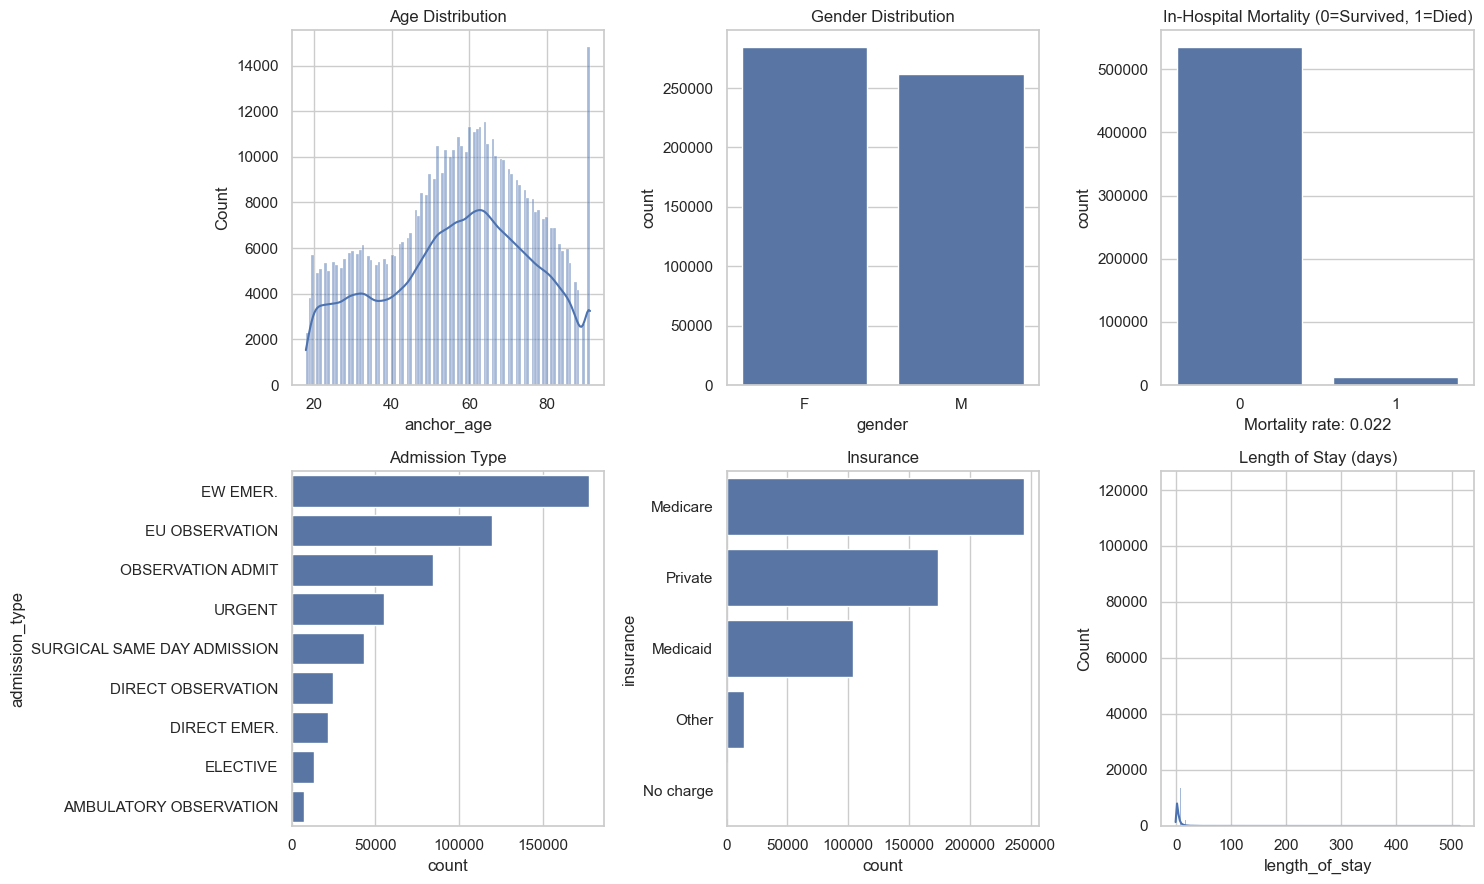

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

if 'anchor_age' in patients_df.columns:
    sns.histplot(patients_df['anchor_age'], kde=True, ax=axes[0,0])
    axes[0,0].set_title('Age Distribution')

if 'gender' in patients_df.columns:
    sns.countplot(x='gender', data=patients_df, ax=axes[0,1])
    axes[0,1].set_title('Gender Distribution')

if 'hospital_expire_flag' in patients_df.columns:
    sns.countplot(x='hospital_expire_flag', data=patients_df, ax=axes[0,2])
    axes[0,2].set_title('In-Hospital Mortality (0=Survived, 1=Died)')
    mortality_rate = patients_df['hospital_expire_flag'].mean()
    axes[0,2].set_xlabel(f'Mortality rate: {mortality_rate:.3f}')

if 'admission_type' in patients_df.columns:
    order = patients_df['admission_type'].value_counts().index
    sns.countplot(y='admission_type', data=patients_df, order=order, ax=axes[1,0])
    axes[1,0].set_title('Admission Type')

if 'insurance' in patients_df.columns:
    order = patients_df['insurance'].value_counts().index
    sns.countplot(y='insurance', data=patients_df, order=order, ax=axes[1,1])
    axes[1,1].set_title('Insurance')

if 'length_of_stay' in patients_df.columns:
    sns.histplot(patients_df['length_of_stay'].dropna(), kde=True, ax=axes[1,2])
    axes[1,2].set_title('Length of Stay (days)')

plt.tight_layout()
plt.show()

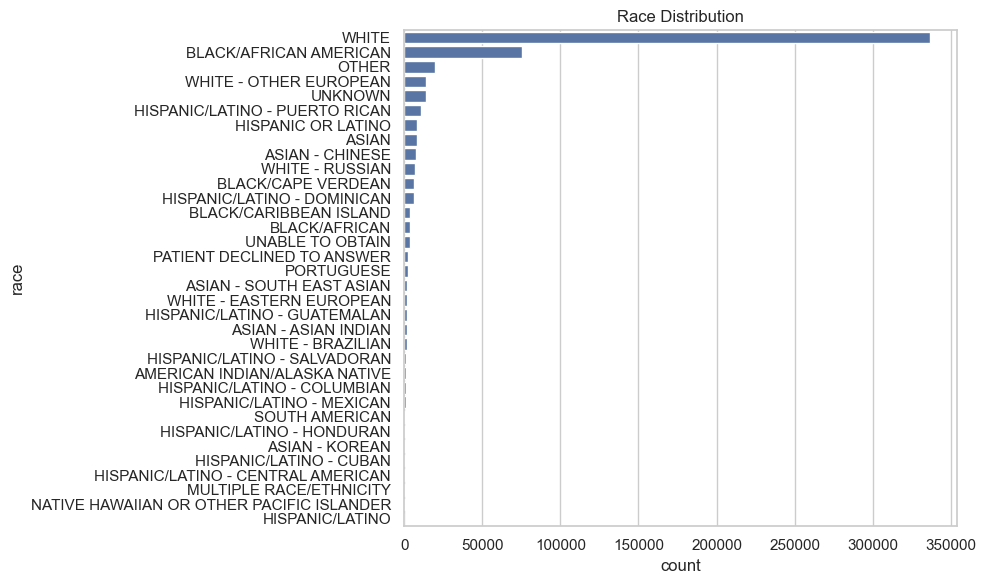

In [6]:
if 'race' in patients_df.columns:
    plt.figure(figsize=(10, 6))
    order = patients_df['race'].value_counts().index
    sns.countplot(y='race', data=patients_df, order=order)
    plt.title('Race Distribution')
    plt.tight_layout()
    plt.show()

## 1.2 Clinical Notes

In [7]:
notes_df = pd.read_csv(PATHS.clinical_notes, engine='python', on_bad_lines='skip')

print("Shape:", notes_df.shape)
print("\nColumns:", notes_df.columns.tolist())
print("\nMissing values:\n", notes_df.isnull().sum())
notes_df.head()

Shape: (1366, 8)

Columns: ['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text']

Missing values:
 note_id         0
subject_id      0
hadm_id       207
note_type       0
note_seq        0
charttime       0
storetime       0
text            0
dtype: int64


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text
0,10000032-RR-14,10000032,22595853.0,RR,14,2180-05-06 21:19:00,2180-05-06 23:32:00,EXAMINATION: CHEST (PA AND LAT)\r\n\r\nINDICA...
1,10000032-RR-15,10000032,22595853.0,RR,15,2180-05-06 23:00:00,2180-05-06 23:26:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ...
2,10000032-RR-16,10000032,22595853.0,RR,16,2180-05-07 09:55:00,2180-05-07 11:15:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hi..."
3,10000032-RR-18,10000032,NaN,RR,18,2180-06-03 12:46:00,2180-06-03 14:01:00,EXAMINATION: Ultrasound-guided paracentesis.\...
4,10000032-RR-20,10000032,NaN,RR,20,2180-07-08 13:18:00,2180-07-08 14:15:00,EXAMINATION: Paracentesis\r\n\r\nINDICATION: ...


Text length stats:
count    1366.000000
mean        1.289898
std         0.529842
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: text_length, dtype: float64


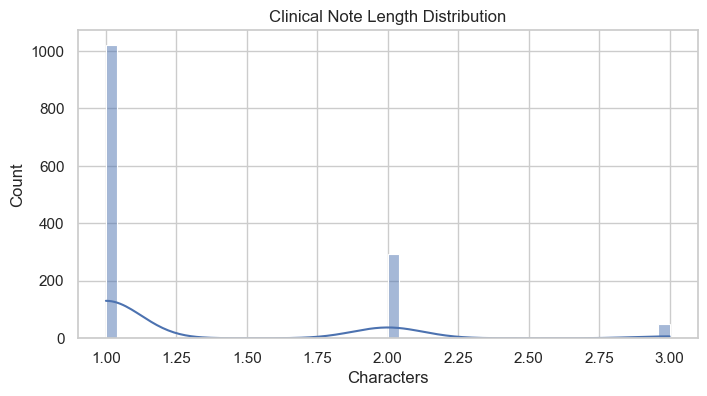

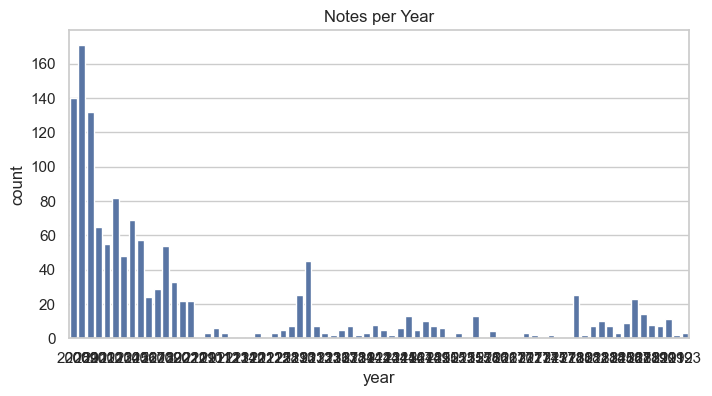

In [8]:
# Note lengths
text_col = 'note_seq' if 'note_seq' in notes_df.columns else ('text' if 'text' in notes_df.columns else None)

if text_col:
    notes_df['text_length'] = notes_df[text_col].astype(str).str.len()
    print("Text length stats:")
    print(notes_df['text_length'].describe())

    plt.figure(figsize=(8, 4))
    sns.histplot(notes_df['text_length'], bins=50, kde=True)
    plt.title('Clinical Note Length Distribution')
    plt.xlabel('Characters')
    plt.show()

if 'charttime' in notes_df.columns:
    notes_df['charttime'] = pd.to_datetime(notes_df['charttime'], errors='coerce')
    notes_df['year'] = notes_df['charttime'].dt.year
    plt.figure(figsize=(8, 4))
    sns.countplot(x='year', data=notes_df)
    plt.title('Notes per Year')
    plt.show()

## 1.3 Lab Events

In [9]:
labs_df = pd.read_csv(PATHS.labs)

print("Shape:", labs_df.shape)
print("\nColumns:", labs_df.columns.tolist())
print("\nMissing values:\n", labs_df.isnull().sum())
labs_df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_15348\3108525895.py:1: DtypeWarning: Columns (36,37,38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  labs_df = pd.read_csv(PATHS.labs)


Shape: (210821, 42)

Columns: ['labevent_id', 'subject_id', 'hadm_id', 'specimen_id', 'itemid', 'order_provider_id_x', 'charttime_x', 'storetime_x', 'value', 'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority', 'comments_x', 'label', 'fluid', 'category', 'microevent_id', 'micro_specimen_id', 'order_provider_id_y', 'chartdate', 'charttime_y', 'spec_itemid', 'spec_type_desc', 'test_seq', 'storedate', 'storetime_y', 'test_itemid', 'test_name', 'org_itemid', 'org_name', 'isolate_num', 'quantity', 'ab_itemid', 'ab_name', 'dilution_text', 'dilution_comparison', 'dilution_value', 'interpretation', 'comments_y']

Missing values:
 labevent_id                 0
subject_id                  0
hadm_id                186060
specimen_id                 0
itemid                      0
order_provider_id_x     69920
charttime_x                 0
storetime_x              5532
value                   33963
valuenum                47241
valueuom                35062
ref_range_l

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id_x,charttime_x,storetime_x,value,valuenum,...,org_name,isolate_num,quantity,ab_itemid,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,comments_y
0,1,10000032,NaN,2704548,50931,P69FQC,2180-03-23 11:51:00,2180-03-23 15:56:00,___,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,___
1,1,10000032,NaN,2704548,50931,P69FQC,2180-03-23 11:51:00,2180-03-23 15:56:00,___,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE FOR TOXOPLASMA IgG ANTIBODY BY EIA. ...
2,1,10000032,NaN,2704548,50931,P69FQC,2180-03-23 11:51:00,2180-03-23 15:56:00,___,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONREACTIVE. Reference Range: Non-Reactive.
3,1,10000032,NaN,2704548,50931,P69FQC,2180-03-23 11:51:00,2180-03-23 15:56:00,___,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POSITIVE BY EIA. A positive IgG result genera...
4,1,10000032,NaN,2704548,50931,P69FQC,2180-03-23 11:51:00,2180-03-23 15:56:00,___,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HIV-1 RNA is not detected. Performed using th...


Top 10 lab items (by itemid):
itemid
50912    5775
50971    5312
50983    5267
50902    5242
51006    5215
50868    5010
50882    5008
51265    4990
51250    4957
51301    4936
Name: count, dtype: int64

valuenum stats:
count    163580.000000
mean         66.857394
std         487.057168
min        -629.000000
25%           4.300000
50%          16.000000
75%          68.000000
max       80472.000000
Name: valuenum, dtype: float64


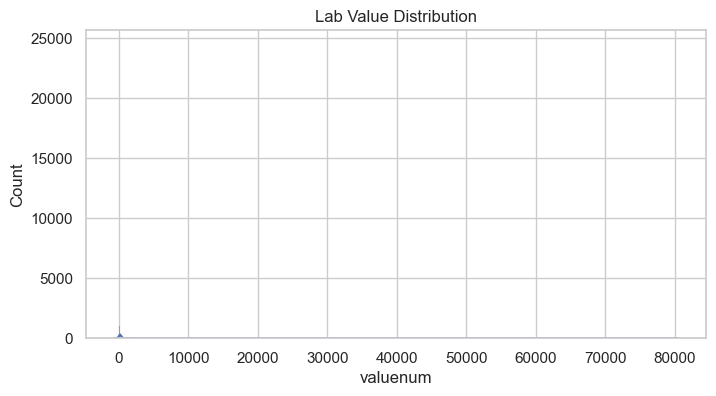

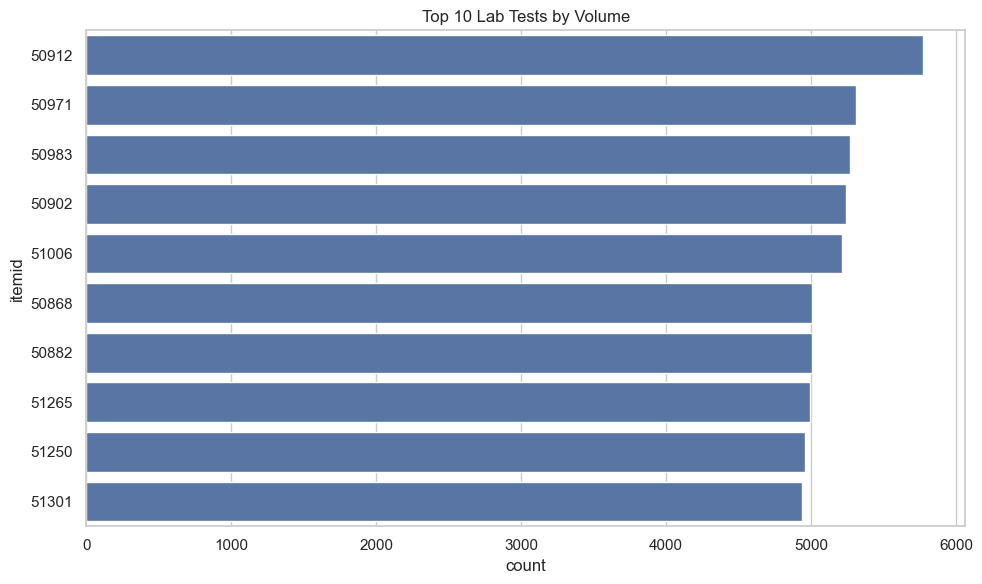

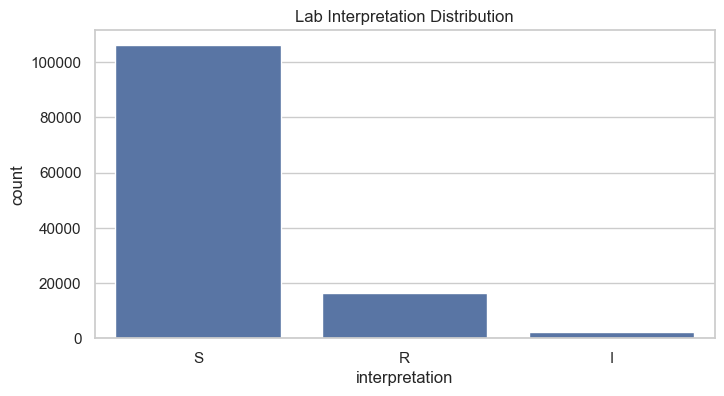

In [10]:
for col in ['charttime', 'storetime']:
    if col in labs_df.columns:
        labs_df[col] = pd.to_datetime(labs_df[col], errors='coerce')

print("Top 10 lab items (by itemid):")
if 'itemid' in labs_df.columns:
    print(labs_df['itemid'].value_counts().head(10))

val_col = 'valuenum' if 'valuenum' in labs_df.columns else 'value'
if val_col in labs_df.columns:
    numeric_vals = pd.to_numeric(labs_df[val_col], errors='coerce').dropna()
    print(f"\n{val_col} stats:")
    print(numeric_vals.describe())

    plt.figure(figsize=(8, 4))
    sns.histplot(numeric_vals, kde=True)
    plt.title('Lab Value Distribution')
    plt.show()

if 'itemid' in labs_df.columns:
    plt.figure(figsize=(10, 6))
    top_items = labs_df['itemid'].value_counts().index[:10]
    sns.countplot(y=labs_df[labs_df['itemid'].isin(top_items)]['itemid'],
                  order=top_items)
    plt.title('Top 10 Lab Tests by Volume')
    plt.tight_layout()
    plt.show()

if 'interpretation' in labs_df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x='interpretation', data=labs_df)
    plt.title('Lab Interpretation Distribution')
    plt.show()

## 1.4 Vital Signs

In [11]:
vitals_df = pd.read_csv(PATHS.vital_signs)

print("Shape:", vitals_df.shape)
print("\nColumns:", vitals_df.columns.tolist())
print("\nMissing values:\n", vitals_df.isnull().sum())
vitals_df.head()

Shape: (173672, 13)

Columns: ['subject_id', 'hadm_id', 'stay_id', 'itemid', 'label', 'category', 'vital_source', 'charttime', 'storetime', 'value', 'valuenum', 'valueuom', 'warning']

Missing values:
 subject_id          0
hadm_id           407
stay_id           407
itemid           1842
label               0
category            0
vital_source        0
charttime           0
storetime        1842
value            1179
valuenum        37883
valueuom        59614
warning          1842
dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15348\2552924970.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  vitals_df = pd.read_csv(PATHS.vital_signs)


,subject_id,hadm_id,stay_id,itemid,label,category,vital_source,charttime,storetime,value,valuenum,valueuom,warning
0,10000032,29079034.0,39553978.0,226512.0,Admission Weight (Kg),General,chartevents,2180-07-23 12:36:00,2180-07-23 14:45:00,39.4,39.4,kg,0.0
1,10000032,29079034.0,39553978.0,223761.0,Temperature Fahrenheit,Routine Vital Signs,chartevents,2180-07-23 14:00:00,2180-07-23 14:20:00,98.7,98.7,°F,0.0
2,10000032,29079034.0,39553978.0,224642.0,Temperature Site,Routine Vital Signs,chartevents,2180-07-23 14:00:00,2180-07-23 14:18:00,Oral,NaN,NaN,0.0
3,10000032,29079034.0,39553978.0,220179.0,Non Invasive Blood Pressure systolic,Routine Vital Signs,chartevents,2180-07-23 14:11:00,2180-07-23 14:17:00,84,84.0,mmHg,0.0
4,10000032,29079034.0,39553978.0,220180.0,Non Invasive Blood Pressure diastolic,Routine Vital Signs,chartevents,2180-07-23 14:11:00,2180-07-23 14:17:00,48,48.0,mmHg,0.0


valuenum stats:
count    135789.000000
mean        104.399007
std         468.769703
min        -100.000000
25%          23.000000
50%          76.000000
75%          98.000000
max      110160.000000
Name: valuenum, dtype: float64


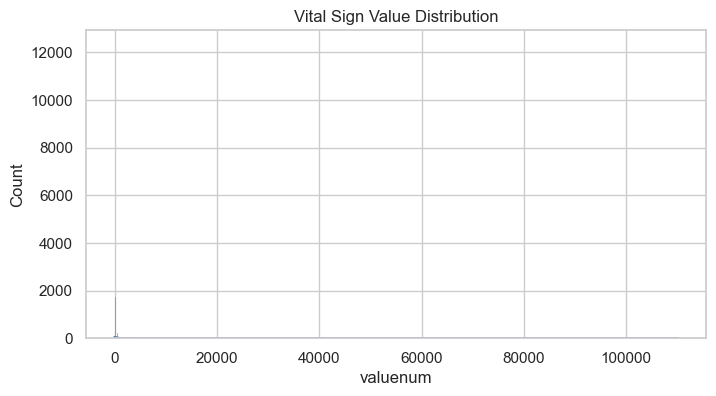


Top vital labels:
label
Respiratory Rate                         8509
O2 saturation pulseoxymetry              8401
Non Invasive Blood Pressure mean         8397
Non Invasive Blood Pressure diastolic    8371
Temperature Fahrenheit                   8369
Admission Weight (Kg)                    8364
Heart Rate                               8361
Non Invasive Blood Pressure systolic     8353
Pain Assessment Method                   2000
Patient Weight                           1435
Name: count, dtype: int64


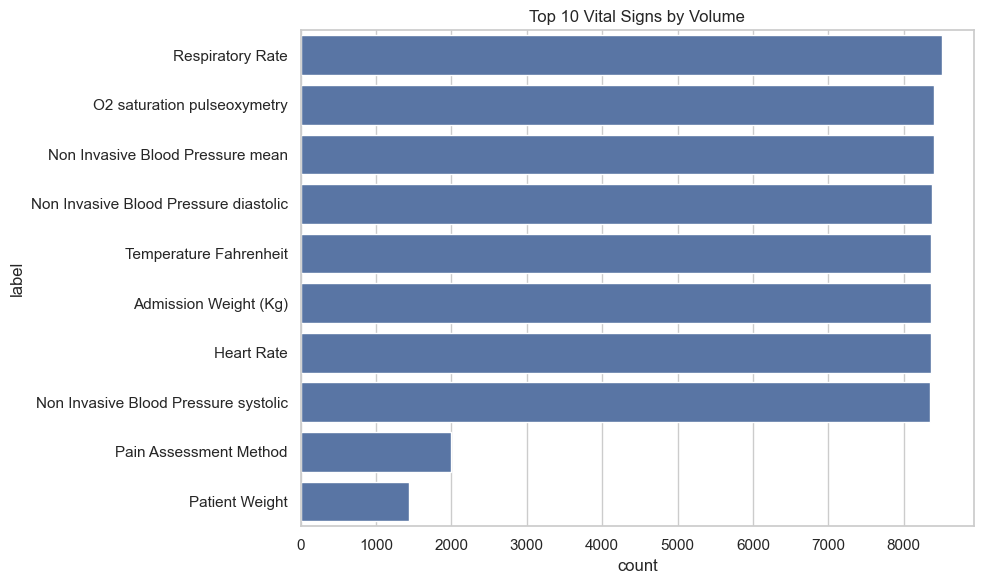

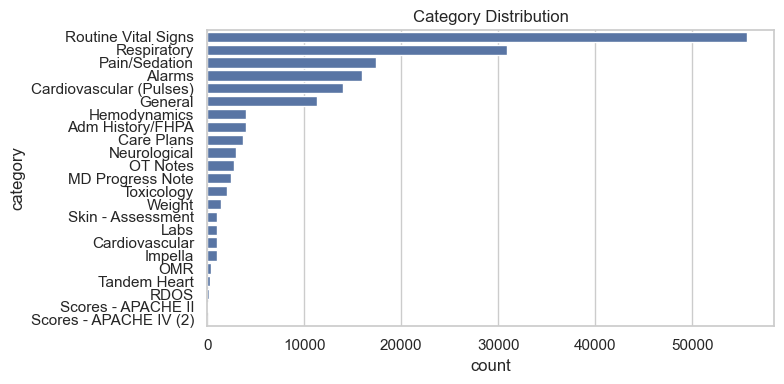

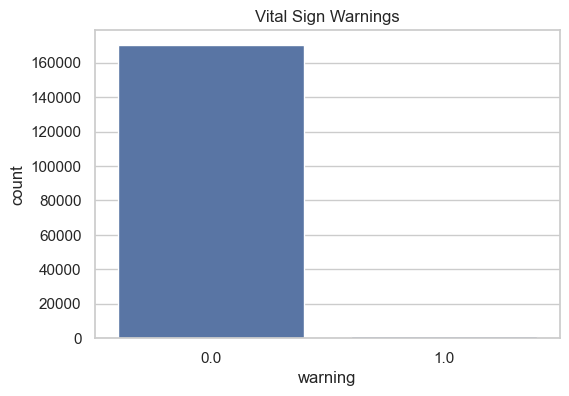

In [12]:
if 'charttime' in vitals_df.columns:
    vitals_df['charttime'] = pd.to_datetime(vitals_df['charttime'], errors='coerce')

val_col = 'valuenum' if 'valuenum' in vitals_df.columns else 'value'
if val_col in vitals_df.columns:
    numeric_vals = pd.to_numeric(vitals_df[val_col], errors='coerce').dropna()
    print(f"{val_col} stats:")
    print(numeric_vals.describe())

    plt.figure(figsize=(8, 4))
    sns.histplot(numeric_vals, kde=True)
    plt.title('Vital Sign Value Distribution')
    plt.show()

if 'label' in vitals_df.columns:
    print("\nTop vital labels:")
    print(vitals_df['label'].value_counts().head(10))
    plt.figure(figsize=(10, 6))
    top_labels = vitals_df['label'].value_counts().index[:10]
    sns.countplot(y=vitals_df[vitals_df['label'].isin(top_labels)]['label'],
                  order=top_labels)
    plt.title('Top 10 Vital Signs by Volume')
    plt.tight_layout()
    plt.show()

if 'category' in vitals_df.columns:
    plt.figure(figsize=(8, 4))
    order = vitals_df['category'].value_counts().index
    sns.countplot(y='category', data=vitals_df, order=order)
    plt.title('Category Distribution')
    plt.tight_layout()
    plt.show()

if 'warning' in vitals_df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='warning', data=vitals_df)
    plt.title('Vital Sign Warnings')
    plt.show()

## 1.5 Cohort Intersection (patients in all 4 tables)

In [13]:
pat_ids = set(patients_df['subject_id'].unique()) if 'subject_id' in patients_df.columns else set()
note_ids = set(notes_df['subject_id'].unique()) if 'subject_id' in notes_df.columns else set()
lab_ids = set(labs_df['subject_id'].unique()) if 'subject_id' in labs_df.columns else set()
vital_ids = set(vitals_df['subject_id'].unique()) if 'subject_id' in vitals_df.columns else set()

cohort = pat_ids & note_ids & lab_ids & vital_ids

print(f"Patients table:   {len(pat_ids):>5} unique subjects")
print(f"Notes table:      {len(note_ids):>5} unique subjects")
print(f"Labs table:       {len(lab_ids):>5} unique subjects")
print(f"Vitals table:     {len(vital_ids):>5} unique subjects")
print(f"\nCohort (all 4):   {len(cohort):>5} subjects")

if 'hospital_expire_flag' in patients_df.columns:
    cohort_patients = patients_df[patients_df['subject_id'].isin(cohort)]
    mort_rate = cohort_patients['hospital_expire_flag'].mean()
    print(f"\nCohort mortality rate: {mort_rate:.3f}")

Patients table:   223937 unique subjects
Notes table:        542 unique subjects
Labs table:         527 unique subjects
Vitals table:      6941 unique subjects

Cohort (all 4):     511 subjects

Cohort mortality rate: 0.259
